<a href="https://colab.research.google.com/github/AishwaryaKalloli/andrejk/blob/main/makemore2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from logging import log
%matplotlib inline

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-04-15 09:52:17--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-04-15 09:52:17 (9.03 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
len(words)

32033

In [ ]:
chars = sorted(list(set(''.join(words))))
len(chars)

26

In [ ]:
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(f"{itos=}")


itos={1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch] # let this be the first Y item

        X.append(context)
        Y.append(ix)

        # print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] + [ix] # maintain the window size / sliding window

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
X[3]

tensor([ 5, 13, 13])

In [ ]:
# now we will create lower dimension where we can squash all the chars, so 27 chars squashed into 2 dimensions

In [ ]:
C = torch.randn((27, 2))

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float()

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.6267, -2.9928])

In [ ]:
C[5]

tensor([ 0.6267, -2.9928])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C == C[5]

tensor([True, True])

# indexing all the Xs

In [ ]:
X[3]

tensor([ 5, 13, 13])

In [ ]:
C[X[3]]

tensor([[ 0.6267, -2.9928],
        [-1.6020, -0.7447],
        [-1.6020, -0.7447]])

In [ ]:
# embedings are dense, lower dimensional vectors which get trained to occupy similar space in lower dimension
# when the words are similar

In [ ]:
# so for each code, between 0 to 26 we have 2 numbers to represent them, instead of 1
# so 0 becomes [something0, something 0]
# 1 becomes [something1, something1]
# 2 becomes [something2, something2] so on

In [ ]:
emb = C[X]

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
#  we are using embedding instead of one hot encoding, which would have made this matrix 16 x 3 x 27,
# where only 1 z column would be 1 and rest 0s

In [ ]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
# we want the first second and thrid char's all the embeddings, separately, then
char_1_all_training_examples = emb[:, 0, :]
char_2_all_training_examples = emb[:, 1, :]
char_3_all_training_examples = emb[:, 2, :]

In [ ]:
char_1_all_training_examples

tensor([[ 1.5881,  0.2210],
        [ 1.5881,  0.2210],
        [ 1.5881,  0.2210],
        ...,
        [ 2.1390,  1.6443],
        [ 2.1390,  1.6443],
        [-0.0029, -0.3914]])

In [ ]:
# we can concatnate the embeddings of 3 chars of each example
# so row 1 = example 1 = [char1 embedding1, char1 embedding2, char2 embedding1, char2 embedding2, char3 embedding1, char3 embedding2]

In [ ]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [ ]:
len(torch.unbind(emb, 1))

3

In [ ]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [ ]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [ ]:
a.shape

torch.Size([18])

In [ ]:
a.view(6, 3)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])

In [ ]:
emb.view(-1, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        ...,
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True]])

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # XW + b

In [ ]:
h.shape

torch.Size([228146, 100])

In [ ]:
W2 = torch.randn(100, 27)
b2 = torch.randn(1, 27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
logits.shape

torch.Size([228146, 27])

In [ ]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)

In [ ]:
prob.shape

torch.Size([228146, 27])

In [ ]:
prob.sum(1)

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])

In [ ]:
prob[torch.arange(X.shape[0]), Y]

tensor([8.9220e-01, 5.6172e-10, 7.6620e-08,  ..., 2.9938e-12, 7.8165e-05,
        1.8962e-11])

In [ ]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(14.7241)

summary

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(1, 27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [ ]:
# forward pass

emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(16), Y].log().mean()
loss = F.cross_entropy(logits, Y)

In [ ]:
# now move in the opposite direction of the gradient
for p in parameters:
    p.grad = None
loss.backward()

for p in parameters:
    p.data += -0.1 * p.grad

In [ ]:
sum(p.nelement() for p in parameters)

3481

In [ ]:
X.shape[0]

228146

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(1, 27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [ ]:
for _ in range(100):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    for p in parameters:
        p.data += -1 * p.grad

19.505226135253906
13.543450355529785
10.424094200134277
9.058489799499512
8.71411418914795
9.057978630065918
7.351500034332275
6.504815101623535
6.401615619659424
6.253350734710693
6.198111057281494
5.477189540863037
5.703056335449219
7.188662052154541
6.419757843017578
4.791476249694824
3.951777219772339
4.45430326461792
4.694777011871338
6.106260776519775
4.772314071655273
4.454538345336914
4.923756122589111
5.562736511230469
4.750213623046875
4.597240447998047
3.8500354290008545
4.784398555755615
3.501610517501831
3.862816572189331
4.549977779388428
5.268613815307617
4.750144004821777
4.889878273010254
3.8024981021881104
4.812894821166992
4.774343967437744
3.801948070526123
3.8627450466156006
3.5347840785980225
4.2845892906188965
4.233729839324951
5.138744831085205
4.434783458709717
3.970790386199951
4.273416519165039
4.419174671173096
3.783663272857666
4.324922561645508
4.477489948272705
3.7748472690582275
3.7282447814941406
3.6414954662323
3.3835997581481934
4.012935161590576
3.7

In [ ]:
logits.max(1)

torch.return_types.max(
values=tensor([7.2041, 6.9048, 6.0718,  ..., 1.1896, 2.9643, 1.4286],
       grad_fn=<MaxBackward0>),
indices=tensor([1, 1, 1,  ..., 0, 9, 9]))

In [ ]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [ ]:
torch.randint(0, X.shape[0], (32, ))

tensor([116710,  33820,  42885, 162018,  22501, 166001, 144211, 183693, 221158,
          4219, 217917,  20753,  71179, 208175,  85016, 210414, 185719, 160767,
        222335,  22433,  17969, 125927,  44878, 133461,  72445,  81252, 161971,
          1158, 221277, 101800, 193886,  32330])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(1, 27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [ ]:
num_steps = 10000
lre = torch.linspace(-3, 0, num_steps)
lrs = 10**lre

In [ ]:
lri, lossi = [], []
for i in range(num_steps):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # Print the current loss (optional)
    # print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad  # Update parameters with gradient descent

    lri.append(lre[i])
    lossi.append(loss.item())

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.5727, grad_fn=<NllLossBackward0>)

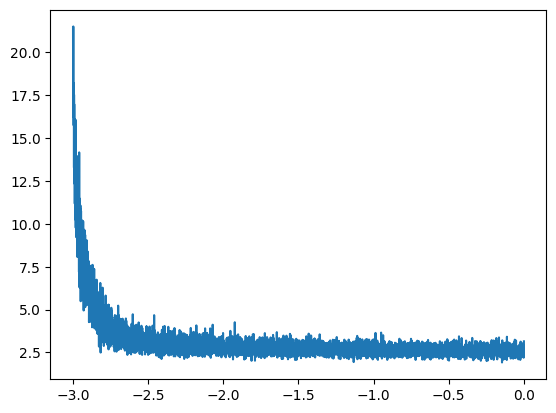

In [ ]:
plt.plot(lri, lossi)

# Clean End to End

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from logging import log
import random
%matplotlib inline

prepare data set

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-04-15 10:26:38--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-04-15 10:26:38 (14.2 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))

stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i: s for s, i in stoi.items()}

print(f"{itos=}")

itos={1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch] # let this be the first Y item

            X.append(context)
            Y.append(ix)

            # print(''.join(itos[i] for i in context), '------>', itos[ix])
            context = context[1:] + [ix] # maintain the window size / sliding window

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f"{X.shape=}, {X.dtype=}, {Y.shape=}, {Y.dtype=}")
    return X, Y

In [ ]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

X.shape=torch.Size([182625, 3]), X.dtype=torch.int64, Y.shape=torch.Size([182625]), Y.dtype=torch.int64
X.shape=torch.Size([22655, 3]), X.dtype=torch.int64, Y.shape=torch.Size([22655]), Y.dtype=torch.int64
X.shape=torch.Size([22866, 3]), X.dtype=torch.int64, Y.shape=torch.Size([22866]), Y.dtype=torch.int64


parameters

In [ ]:
g = torch.Generator().manual_seed(2147483647)
embedding_size = 27
C = torch.randn((27, embedding_size), generator=g, requires_grad=True)
W1 = torch.randn((block_size * embedding_size, 300), generator=g, requires_grad=True)
b1 = torch.randn(300, generator=g, requires_grad=True)
W2 = torch.randn((300, 27), generator=g, requires_grad=True)
b2 = torch.randn(1, 27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [ ]:
batch_size = 160

In [ ]:
sum(p.nelement() for p in parameters)

33456

In [ ]:
NUM_RUNS = 60000

In [ ]:
lre = torch.linspace(-5, 1, NUM_RUNS)
lrs = 10**lre

optimisation

In [ ]:
stepi, lri, lossi = [], [], []

In [ ]:
for i in range(NUM_RUNS):
    # minibatch construct
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))

    emb = C[Xtrain[ix]]
    h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytrain[ix])

    # Print the current loss (optional)
    # print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = 0.1 if i < 100000 else 0.01
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad  # Update parameters with gradient descent

    stepi.append(i)
    lri.append(lre[i])
    lossi.append(loss.item())

In [ ]:
min(lossi)

2.8879504203796387

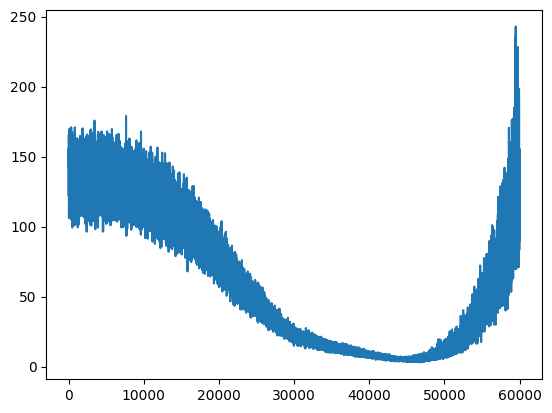

In [ ]:
plt.plot(stepi, lossi)

forward pass

In [ ]:
emb = C[Xtrain]
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(124.2928, grad_fn=<NllLossBackward0>)

test on dev dataset

In [ ]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(125.0197, grad_fn=<NllLossBackward0>)

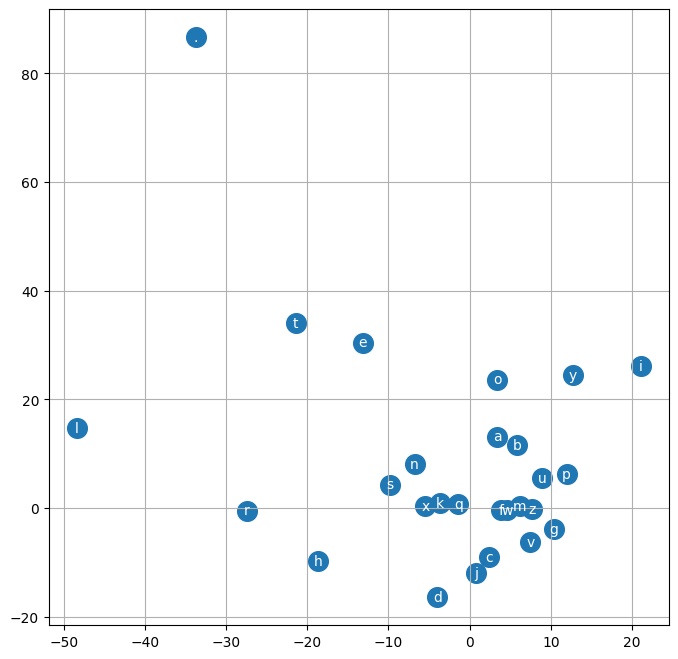

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")